# mbd_datasets2: theta=0.1pi, coherent noise

Build graphs from `../../tutorials/data/mbd_datasets2/theta_0.1pi_coherent/train`, train the graph-Transformer QEM model (`QEMGraphTransformer`), train a per-qubit Random Forest baseline on the same split, and compare both against the ideal expectation values on the validation split.

Unlike the Brisbane hardware notebooks, this dataset already carries `ideal_exp_value` / `noisy_exp_values` per circuit, so there is no ZNE-derivation step -- labels come straight from the data.

In [1]:
import sys, os, json, importlib, random, pickle
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from qiskit.dagcircuit import DAGOpNode

# lightcone.assign_moments (dag.layers()-based) silently drops some
# nodes (e.g. barriers) in some qiskit versions; use a topological-order
# version instead, matching 01_build_graphs.ipynb's fix.
def assign_moments_topo(dag):
    moments = {}
    for node in dag.topological_op_nodes():
        preds = [e.node for e in dag.predecessors(node)
                 if hasattr(e, "node") and isinstance(e.node, DAGOpNode)]
        moments[node] = 0 if not preds else 1 + max(moments[p] for p in preds)
    return moments

import lightcone
lightcone.assign_moments = assign_moments_topo
import circuits_to_graph
importlib.reload(circuits_to_graph)
import dataset
importlib.reload(dataset)

from schemas import ConvertConfig
from sim_data_utils import (
    build_labels_csv, attach_labels_and_noisy_exact, build_measured_qubits_map,
    stage_flat_dir, convert_qasm_json_dir_to_pk, load_circuit_label_lists,
)
from data_utils import load_graphs, build_loaders
from torch_geometric.loader import DataLoader
from train_loop import train, evaluate
from model import QEMGraphTransformer
from mlp import encode_data_v2_ecr
from sklearn.ensemble import RandomForestRegressor

In [2]:
DATASET_NAME = 'mbd_theta_0p1pi_coherent'
RAW_TRAIN_DIR = '../../tutorials/data/mbd_datasets2/theta_0.1pi_coherent/train'
RAW_VAL_DIR = '../../tutorials/data/mbd_datasets2/theta_0.1pi_coherent/val'  # None if no usable val split exists
RUN_DIR = f"runs/{DATASET_NAME}"
os.makedirs(RUN_DIR, exist_ok=True)

In [3]:
TRAIN_DIR = RAW_TRAIN_DIR
VAL_DIR = RAW_VAL_DIR

**Per-circuit measured-qubit map.** `ideal_exp_value[i]` / `noisy_exp_values[i]` are indexed by *classical-bit* order, but neither the set nor the order of physically measured qubits is fixed across circuits here -- it shifts across Trotter steps and even varies circuit-to-circuit within a step. Passing a flat `[0, 1, 2, 3]` as the measured-qubit list would silently mislabel the graph's lightcone columns (and for many circuits leaves a 'measured' column with an empty lightcone -> NaN loss). So instead we derive the correct per-circuit qubit order straight from each circuit's own `measure` instructions.

In [4]:
def build_split(input_dir, split):
    measured_map_json = build_measured_qubits_map(
        input_dir, f"{RUN_DIR}/measured_map_{split}.json", file_extensions=[".pk"],
    )
    cfg = ConvertConfig(
        input_dir=input_dir, split=split,
        output_path=f"{RUN_DIR}/processed/graphs_{split}.pt",
        measured_qubits=None, measured_map_json=measured_map_json,
        max_params=2, verbose=True,
        file_extensions=[".pk"],
    )
    dataset.convert_folder_to_pt(cfg)
    build_labels_csv(input_dir, f"{RUN_DIR}/labels_{split}.csv", file_extensions=[".pk"])
    graphs = load_graphs(cfg.output_path)
    graphs, M = attach_labels_and_noisy_exact(graphs, f"{RUN_DIR}/labels_{split}.csv")
    return graphs, M

train_graphs, M = build_split(TRAIN_DIR, "train")
print(f"train graphs: {len(train_graphs)} | M={M}")

if VAL_DIR is not None:
    val_graphs, M_val = build_split(VAL_DIR, "val")
    assert M_val == M
    print(f"val graphs: {len(val_graphs)} | M={M_val}")
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=16, shuffle=False)
else:
    print("No usable val split for this dataset; using an internal 80/20 split of train.")
    train_loader, val_loader = build_loaders(train_graphs, batch_size=16, val_frac=0.2, seed=42)

Processing...


Converting train circuits:   0%|          | 0/5000 [00:00<?, ?circuit/s]

Done!


train graphs: 5000 | M=4


Processing...


Converting val circuits:   0%|          | 0/2000 [00:00<?, ?circuit/s]

Done!


val graphs: 2000 | M=4


In [5]:
model_cfg = dict(d_model=128, layers=3, heads=4, dropout=0.1, use_noisy=True)
net, hist = train(model_cfg, (train_loader, val_loader), epochs=100, lr=1e-3, wd=1e-4,
                   patience=30, device='cpu',
                   best_ckpt_path=f"{RUN_DIR}/best_qem_graph_transformer.pt")
total_params = sum(p.numel() for p in net.parameters())
print("Total params:", total_params)

Epoch 001 | train 0.0508 | val 0.0366 | MAE 0.1565


Epoch 002 | train 0.0260 | val 0.0234 | MAE 0.1232


Epoch 003 | train 0.0237 | val 0.0214 | MAE 0.1078


Epoch 004 | train 0.0232 | val 0.0221 | MAE 0.1201


Epoch 005 | train 0.0228 | val 0.0223 | MAE 0.1109


...

Epoch 096 | train 0.0059 | val 0.0071 | MAE 0.0675


Epoch 097 | train 0.0061 | val 0.0071 | MAE 0.0715


Epoch 098 | train 0.0060 | val 0.0057 | MAE 0.0647


Epoch 099 | train 0.0061 | val 0.0058 | MAE 0.0611


Epoch 100 | train 0.0057 | val 0.0077 | MAE 0.0674
Loaded best model from epoch 99 (val MAE=0.0611).
Total params: 251393


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
net.to(device)

@torch.no_grad()
def collect_pred_target_noisy(loader, model, M, device):
    model.eval()
    P, Y, N = [], [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)
        P.append(y_hat.detach().cpu()); Y.append(batch.y.detach().cpu()); N.append(batch.noisy_z.detach().cpu())
    return torch.cat(P).view(-1, M), torch.cat(Y).view(-1, M), torch.cat(N).view(-1, M)

P, Y, N = collect_pred_target_noisy(val_loader, net, M, device)
gnn_mae = (P - Y).abs().mean(dim=0).tolist()
print("Per-qubit MAE (GNN):", gnn_mae)

Per-qubit MAE (GNN): [0.044149622321128845, 0.11428659409284592, 0.0350249819457531, 0.05078168585896492]


## Random Forest baseline

Trained/evaluated on the *same* train/val circuits as the GNN (matched by `circuit_path`).

In [7]:
train_paths_set = {g.circuit_path for g in train_loader.dataset}
val_paths_set = {g.circuit_path for g in val_loader.dataset}

def gather_split(input_dir, wanted_paths):
    paths, circuits, ideal, noisy = load_circuit_label_lists(input_dir, file_extensions=[".pk"])
    keep = [i for i, p in enumerate(paths) if p in wanted_paths]
    return [circuits[i] for i in keep], [ideal[i] for i in keep], [noisy[i] for i in keep]

train_circuits, train_ideal, train_noisy = gather_split(TRAIN_DIR, train_paths_set)
val_source_dir = VAL_DIR if VAL_DIR is not None else TRAIN_DIR
val_circuits, val_ideal, val_noisy = gather_split(val_source_dir, val_paths_set)
print(f"RF train circuits: {len(train_circuits)} | RF val circuits: {len(val_circuits)}")

RF train circuits: 5000 | RF val circuits: 2000


In [8]:
X_train, y_train = encode_data_v2_ecr(train_circuits, train_ideal, train_noisy, obs_size=M, two_q_gate='cx')
X_val, y_val = encode_data_v2_ecr(val_circuits, val_ideal, val_noisy, obs_size=M, two_q_gate='cx')

rf_models = []
for q in range(M):
    rfr = RandomForestRegressor(n_estimators=100, n_jobs=-1)
    rfr.fit(X_train.numpy(), y_train.numpy()[:, q])
    rf_models.append(rfr)
    print(f"RF trained for qubit {q}")

rf_preds = np.stack([m.predict(X_val.numpy()) for m in rf_models], axis=1)
rf_mae = np.abs(rf_preds - y_val.numpy()).mean(axis=0).tolist()
print("Per-qubit MAE (RF):", rf_mae)

RF trained for qubit 0


RF trained for qubit 1


RF trained for qubit 2


RF trained for qubit 3


Per-qubit MAE (RF): [0.040131558809075464, 0.12723614725621168, 0.02841997822508214, 0.032880697222911995]


## Comparison: unmitigated noisy vs RF vs GNN

In [9]:
noisy_np = N.numpy()
gnn_np = P.numpy()
ideal_np = Y.numpy()

def rmse_per_qubit(pred, ideal):
    return np.sqrt(((pred - ideal) ** 2).mean(axis=0))

rmse_noisy = rmse_per_qubit(noisy_np, ideal_np)
rmse_gnn = rmse_per_qubit(gnn_np, ideal_np)
rmse_rf = rmse_per_qubit(rf_preds, y_val.numpy())

results = pd.DataFrame({
    "qubit": [f"q{q}" for q in range(M)],
    "rmse_noisy": rmse_noisy,
    "rmse_rf": rmse_rf,
    "rmse_gnn": rmse_gnn,
})
overall = pd.DataFrame([{"qubit": "overall", "rmse_noisy": rmse_noisy.mean(),
                        "rmse_rf": rmse_rf.mean(), "rmse_gnn": rmse_gnn.mean()}])
results = pd.concat([results, overall], ignore_index=True)
print(results)

results.to_csv(f"{RUN_DIR}/comparison_results.csv", index=False)
with open(f"{RUN_DIR}/comparison_results.json", "w") as f:
    json.dump({
        "dataset": DATASET_NAME,
        "rmse_noisy": rmse_noisy.tolist(), "rmse_rf": rmse_rf.tolist(), "rmse_gnn": rmse_gnn.tolist(),
        "n_train": len(train_loader.dataset), "n_val": len(val_loader.dataset),
    }, f, indent=2)

     qubit  rmse_noisy   rmse_rf  rmse_gnn
0       q0    0.221389  0.076291  0.074836
1       q1    0.411864  0.202887  0.171465
2       q2    0.112885  0.064398  0.060872
3       q3    0.167401  0.074185  0.088109
4  overall    0.228385  0.104440  0.098820


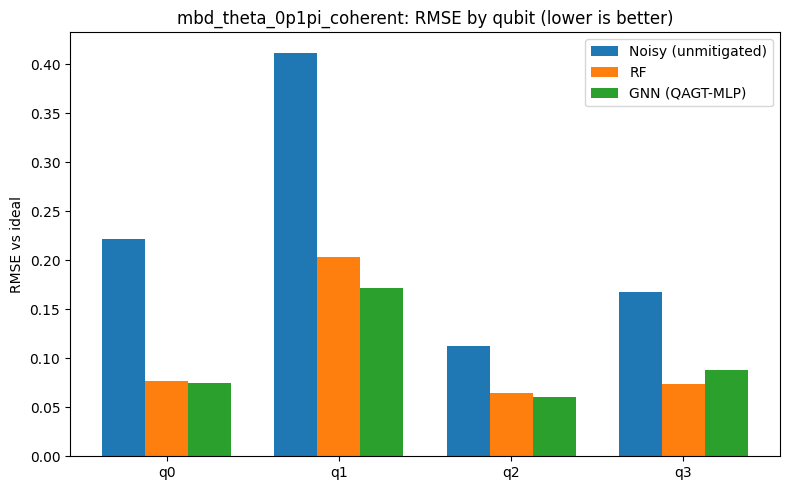

In [10]:
x = np.arange(M)
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, rmse_noisy, width, label="Noisy (unmitigated)")
plt.bar(x, rmse_rf, width, label="RF")
plt.bar(x + width, rmse_gnn, width, label="GNN (QAGT-MLP)")
plt.xticks(x, [f"q{q}" for q in range(M)])
plt.ylabel("RMSE vs ideal")
plt.title(f"{DATASET_NAME}: RMSE by qubit (lower is better)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/rmse_comparison.png")
plt.show()

## Tier 0 + Tier 1: discrete-level head and a configurable training loop

Opt-in additions living in `qem_levels.py` / `qem_ext.py` / `qem_train.py`. `model.py` and
`train_loop.py` are untouched, so every cell above keeps its original behaviour --
`QEMGraphTransformerX(head="scalar")` has a bit-identical `state_dict` to
`QEMGraphTransformer`, and `TrainConfig()`'s defaults reproduce the original loop exactly.

**Tier 0 -- match the head to the target distribution.** Some of these datasets have
targets that are not continuous: random Clifford circuits give `<Z>` in {-1, 0, +1}
exactly. Regressing on such a target makes the model hedge -- it emits 0.87 where the
truth is 1.0 and pays MAE on a point whose class it already got right.
`LevelSet.detect` inspects the **training** labels only and returns a level set just when
they really do collapse onto a few atoms, otherwise `None`, in which case the cells below
fall back to regression. Across this repo it fires for `haoran_mbd/random_cliffords` and
`haoran_mbd_coherent/random_cliffords`, and returns `None` for the `ising_*`,
`mbd_theta_*` and `random_brickwork` datasets.

**Tier 1 -- training-loop fixes.** `nn.SmoothL1Loss()` defaults to `beta=1.0`, and every
residual here lives in [-2, 2], so the loss never leaves the quadratic regime: it is
exactly `0.5*MSE`, with none of the robustness the name suggests. The LR was held constant
for the whole run. And a single unseeded run is not a like-for-like comparison against a
100-tree forest. `TrainConfig` exposes all three.

Both new heads zero-initialise their last layer, so training *starts* at a known baseline
and can only improve on it: `residual` starts at `y_hat = noisy_z` (the unmitigated
value), and `level` carries a `-gamma*(noisy_z - l_k)^2` prior term so its argmax at step 0
is exactly "snap `noisy_z` to the nearest level".

In [11]:
import qem_levels, qem_ext, qem_train
importlib.reload(qem_levels); importlib.reload(qem_ext); importlib.reload(qem_train)

from qem_levels import LevelSet, level_report
from qem_ext import QEMGraphTransformerX
from qem_train import TrainConfig, train_qem, train_ensemble, collect, ensemble_predict, metrics

# Detect the level set from the TRAINING labels only (never the val split).
# Returns None when the targets are genuinely continuous -- the next cell then
# falls back to the residual regression head.
y_train_all = torch.cat([d.y for d in train_loader.dataset])
levels = LevelSet.detect(y_train_all)
print(levels, "|", level_report(y_train_all, levels))

None | no discrete level set detected -> continuous regression


In [12]:
# Capacity/dropout follow Tier 1: the original run underfits, so keep d_model at
# least 64 and drop the dropout that was regularising overfitting that isn't
# there. Layers/heads match model_cfg from the cell above.
cfg_common = dict(d_model=max(64, model_cfg["d_model"]),
                  layers=model_cfg["layers"], heads=model_cfg["heads"],
                  dropout=0.05, use_noisy=True)

if levels is not None:
    # Tier 0: K-way classification over the detected levels.
    model_cfg_x = dict(cfg_common, head="level", levels=levels)
    train_cfg = TrainConfig(epochs=80, lr=1e-3, wd=1e-4, patience=25,
                            loss="ce", scheduler="cosine", warmup_epochs=5,
                            select_on="acc", seed=0)
else:
    # Continuous targets: stay a regressor, but keep the Tier 1 fixes --
    # residual head, a beta that actually reaches the linear regime, cosine LR.
    model_cfg_x = dict(cfg_common, head="residual")
    train_cfg = TrainConfig(epochs=80, lr=1e-3, wd=1e-4, patience=25,
                            loss="smooth_l1", huber_beta=0.05, scheduler="cosine",
                            warmup_epochs=5, select_on="mae", seed=0)

net_x, hist_x = train_qem(model_cfg_x, (train_loader, val_loader), train_cfg,
                          best_ckpt_path=f"{RUN_DIR}/best_qem_x.pt")
print("Total params:", sum(p.numel() for p in net_x.parameters()))

Epoch 001 | train 0.0917 | MAE 0.1104 | RMSE 0.2316 | lr 2.00e-04


Epoch 002 | train 0.0885 | MAE 0.1129 | RMSE 0.2325 | lr 4.00e-04


Epoch 003 | train 0.0888 | MAE 0.1084 | RMSE 0.2311 | lr 6.00e-04


Epoch 004 | train 0.0869 | MAE 0.1069 | RMSE 0.2210 | lr 8.00e-04


Epoch 005 | train 0.0846 | MAE 0.1007 | RMSE 0.2131 | lr 1.00e-03


...

Epoch 076 | train 0.0370 | MAE 0.0521 | RMSE 0.1036 | lr 2.08e-05


Epoch 077 | train 0.0372 | MAE 0.0524 | RMSE 0.1039 | lr 1.69e-05


Epoch 078 | train 0.0371 | MAE 0.0520 | RMSE 0.1031 | lr 1.39e-05


Epoch 079 | train 0.0366 | MAE 0.0524 | RMSE 0.1039 | lr 1.17e-05


Epoch 080 | train 0.0369 | MAE 0.0522 | RMSE 0.1038 | lr 1.04e-05
Loaded best model from epoch 78 (val mae=0.0520).
Total params: 251393


In [13]:
# 5-seed ensemble -- a single unseeded run is not comparable to a 100-tree forest.
nets_x, hists_x = train_ensemble(
    model_cfg_x, (train_loader, val_loader),
    TrainConfig(**{**train_cfg.__dict__, "verbose": False}),
    seeds=(0, 1, 2, 3, 4), ckpt_prefix=f"{RUN_DIR}/qem_x",
)
print(f"trained {len(nets_x)} members")

trained 5 members


In [14]:
from sklearn.ensemble import RandomForestClassifier

rows = {}
rows["Noisy (unmitigated)"] = metrics(noisy_np, ideal_np, levels)
rows["RF regressor"] = metrics(rf_preds, y_val.numpy(), levels)
rows["QAGT-MLP original (raw)"] = metrics(gnn_np, ideal_np, levels)

if levels is not None:
    lv = np.asarray(levels.levels)
    to_cls = lambda a: np.abs(np.asarray(a)[..., None] - lv).argmin(-1)
    snap_np = lambda a: lv[to_cls(a)]

    # Snapping costs nothing and applies to every baseline, so compare like with like.
    rows["Noisy, snapped"] = metrics(snap_np(noisy_np), ideal_np, levels)
    rows["RF regressor, snapped"] = metrics(snap_np(rf_preds), y_val.numpy(), levels)
    rf_clf_pred = np.stack([
        lv[RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0)
           .fit(X_train.numpy(), to_cls(y_train.numpy())[:, q]).predict(X_val.numpy())]
        for q in range(M)
    ], axis=1)
    rows["RF classifier"] = metrics(rf_clf_pred, y_val.numpy(), levels)
    rows["QAGT-MLP original (snapped)"] = metrics(snap_np(gnn_np), ideal_np, levels)

# argmax is the MAE-optimal decoding of the level head; sum_k p_k * l_k is the
# RMSE-optimal one (hedging *is* correct under squared error). Report both.
raw_x, y_x, _ = collect(net_x, val_loader, device)
modes = ("argmax", "expect") if net_x.is_classifier else ("raw",)
for mode in modes:
    rows[f"QAGT-MLP Tier0+1, 1 seed ({mode})"] = metrics(
        net_x.decode(raw_x, mode).numpy(), y_x.numpy(), levels)
for mode in modes:
    p_ens, y_ens, _ = ensemble_predict(nets_x, val_loader, device, decode=mode)
    rows[f"QAGT-MLP Tier0+1, 5-seed ens ({mode})"] = metrics(p_ens, y_ens, levels)

comparison = pd.DataFrame(rows).T
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))
comparison.to_csv(f"{RUN_DIR}/comparison_tier01.csv")

                                      mae   rmse
Noisy (unmitigated)                0.1605 0.2547
RF regressor                       0.0572 0.1190
QAGT-MLP original (raw)            0.0611 0.1078
QAGT-MLP Tier0+1, 1 seed (raw)     0.0520 0.1031
QAGT-MLP Tier0+1, 5-seed ens (raw) 0.0427 0.0832


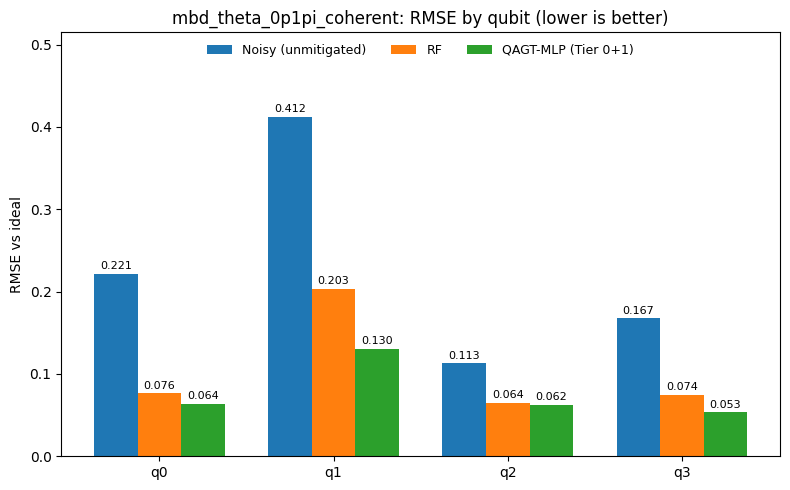

  qubit  rmse_noisy  rmse_rf  rmse_qagt
     q0      0.2214   0.0763     0.0639
     q1      0.4119   0.2029     0.1300
     q2      0.1129   0.0644     0.0620
     q3      0.1674   0.0742     0.0534
overall      0.2284   0.1044     0.0773


In [15]:
# Per-qubit RMSE: unmitigated vs RF vs QAGT-MLP (Tier 0+1), same style as the
# figure above. A level head is decoded with "expect" (sum_k p_k * l_k), which
# is the RMSE-optimal decoding -- and RMSE is what this figure reports.
p_fig, y_fig, _ = ensemble_predict(nets_x, val_loader, device,
                                   decode="expect" if net_x.is_classifier else "raw")
p_fig = p_fig.reshape(-1, M)
y_fig = y_fig.reshape(-1, M)

rmse_un_x = rmse_per_qubit(noisy_np, ideal_np)
rmse_rf_x = rmse_per_qubit(rf_preds, y_val.numpy())
rmse_qagt_x = rmse_per_qubit(p_fig, y_fig)

x = np.arange(M)
width = 0.25
plt.figure(figsize=(8, 5))
bars = [
    plt.bar(x - width, rmse_un_x, width, label="Noisy (unmitigated)"),
    plt.bar(x, rmse_rf_x, width, label="RF"),
    plt.bar(x + width, rmse_qagt_x, width, label="QAGT-MLP (Tier 0+1)"),
]
for b in bars:
    plt.bar_label(b, fmt="%.3f", fontsize=8, padding=2)
# headroom so the legend never sits on top of a bar label
plt.ylim(0, max(rmse_un_x.max(), rmse_rf_x.max(), rmse_qagt_x.max()) * 1.25)
plt.xticks(x, [f"q{q}" for q in range(M)])
plt.ylabel("RMSE vs ideal")
plt.title(f"{DATASET_NAME}: RMSE by qubit (lower is better)")
plt.legend(loc="upper center", ncol=3, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/rmse_comparison_tier01.png", dpi=150)
plt.show()

rmse_table = pd.DataFrame({
    "qubit": [f"q{q}" for q in range(M)] + ["overall"],
    "rmse_noisy": list(rmse_un_x) + [rmse_un_x.mean()],
    "rmse_rf": list(rmse_rf_x) + [rmse_rf_x.mean()],
    "rmse_qagt": list(rmse_qagt_x) + [rmse_qagt_x.mean()],
})
print(rmse_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
rmse_table.to_csv(f"{RUN_DIR}/rmse_comparison_tier01.csv", index=False)